In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import warnings
import os
import math
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [3]:
os.chdir("../") # set cwd to root dir

**Figure out if all timestamps for core foot params match the interim data**

In [4]:
num_participants = 18

In [5]:
foot_df = pd.DataFrame()

for i in range(0, num_participants):
    pid = i+1

    if not os.path.exists(f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/left_foot_core_params.csv") or not f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/right_foot_core_params.csv" or not f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/left_foot_core_params.csv" or not f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/right_foot_core_params.csv":
        continue

    lf_control_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/left_foot_core_params.csv")
    lf_control_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    lf_control_df['Setup'] = 'Control + LF'
    lf_control_df['Participant'] = pid

    rf_control_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_control/sub_{pid:02}/right_foot_core_params.csv")
    rf_control_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    rf_control_df['Setup'] = 'Control + RF'
    rf_control_df['Participant'] = pid

    lf_fatigue_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/left_foot_core_params.csv")
    lf_fatigue_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    lf_fatigue_df['Setup'] = 'Fatigue + LF'
    lf_fatigue_df['Participant'] = pid

    rf_fatigue_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{pid:02}/right_foot_core_params.csv")
    rf_fatigue_df.rename({ "timestamps": "Time (secs)" }, axis=1, inplace=True)
    rf_fatigue_df['Setup'] = 'Fatigue + RF'
    rf_fatigue_df['Participant'] = pid

    foot_df = pd.concat([foot_df, lf_control_df, rf_control_df, lf_fatigue_df, rf_fatigue_df], axis=0)

In [6]:
foot_df = foot_df[foot_df['stride_index']==0] # keep only 1st stride
foot_df = foot_df[['Participant', 'Time (secs)', 'fo_samples', 'ic_samples', 'fo_times', 'ic_times', 'Setup']] # keep only relevant info
foot_df = foot_df.sort_values(by='Participant')

foot_df

,Participant,Time (secs),fo_samples,ic_samples,fo_times,ic_times,Setup
0,1,5.02344,729,795,5.69531,6.21094,Control + LF
0,1,4.43750,656,718,5.12500,5.60938,Control + RF
0,1,1.89844,331,390,2.58594,3.04687,Fatigue + LF
0,1,2.46094,406,465,3.17187,3.63281,Fatigue + RF
0,2,2.80469,440,501,3.43750,3.91406,Control + LF
...,...,...,...,...,...,...,...
0,17,3.10937,464,523,3.62500,4.08594,Fatigue + RF
0,18,1.61719,301,366,2.35156,2.85938,Fatigue + LF
0,18,2.16406,364,428,2.84375,3.34375,Control + LF
0,18,2.75781,439,501,3.42969,3.91406,Control + RF


In [7]:
matched_row_counts = []

for index, row in foot_df.iterrows():
    pid = row['Participant']
    target_time = row['Time (secs)']
    
    fatigue_df = pd.read_csv(f"data/DUO-GAIT/interim/OG_st_control/sub_{pid:02}/LF.csv")
    fatigue_df.rename({ "timestamp": "Time (secs)" }, axis=1, inplace=True)
    fatigue_df['Delta (secs)'] = fatigue_df['Time (secs)'] - fatigue_df['Time (secs)'].min() # delta time

    matched_counts = fatigue_df['Delta (secs)'].apply(lambda x: math.isclose(x, target_time, rel_tol=1e-5)).sum() # get number of matched rows in interim files
    matched_row_counts.append(matched_counts)

matched_row_counts_df = pd.DataFrame({'counts': matched_row_counts})

**Ensure matched row counts equal to 1 for all rows**

<Axes: xlabel='counts', ylabel='count'>

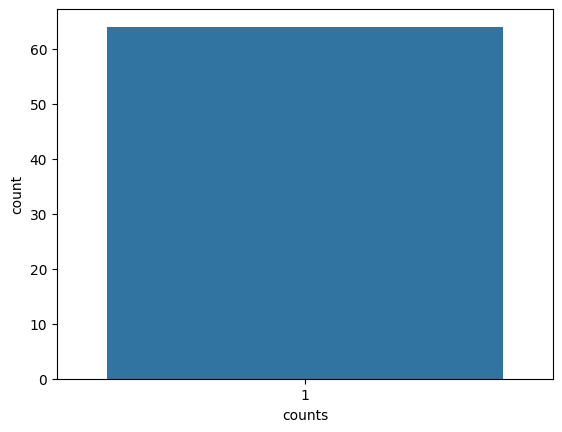

In [8]:
sns.countplot(matched_row_counts_df, x='counts')

**1e-5** tolerance matches everything to exactly **1** count. From here, everything can be extracted due to having sample ranges and initial sample number.